# 03 — `ativo_total`/`credito_total`: volatilidade da série e a hipótese das agências

Extensão pontual do `01_eda_painel_2015_2025.ipynb`: durante a univariada, `ativo_total` e `credito_total` apareceram cruzados com o câmbio nos meses de outlier (ver seção correspondente no notebook 01). Este notebook formaliza duas coisas que o 01 só apontou, sem confirmar:

1. **Confirmar o padrão** — existe mesmo uma mudança relevante em `ativo_total`/`credito_total`, ou é impressão da tabela de outliers? (Spoiler: existe, mas não é o que a gente esperava — não é uma quebra pontual em 2019-2020, é uma volatilidade estrutural que a série tem o tempo todo.)
2. **Testar a hipótese das agências** — o fechamento de agências bancárias físicas em Santos (mesma fonte, ESTBAN) explica esse padrão? Testado por banco desde o início: a alternativa a "o mercado como um todo mudou" sempre foi "um agente específico distorceu o agregado", e essa alternativa só é testável olhando por instituição. Como parte desse teste, a série por banco (2015-2025) também é usada para checar se algum ano tem buraco de reporte que pudesse ser confundido com volatilidade real — checagem que se mostrou relevante: 2025 tem, os anos anteriores não.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

painel = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/processed/painel_2015_2025.csv')
agencias = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/raw/estban_agencias_santos_2015-2025.csv')
agencias_por_banco = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/raw/estban_agencias_santos_2015-2025_por_banco.csv')

painel.head(2)


## 1. Confirmando o padrão em `ativo_total`/`credito_total`

O notebook 01 mostrou que `ativo_total` e `credito_total` sobem/caem juntos e aparecem cruzados com câmbio nos meses de outlier — mas isso foi lido direto da tabela de outliers (que usa o IQR do período inteiro), não de uma visão temporal. Aqui olhamos a evolução ano a ano de verdade — inclusive pra checar se a hipótese inicial de uma "quebra pontual em 2019-2020" é mesmo o achado certo.


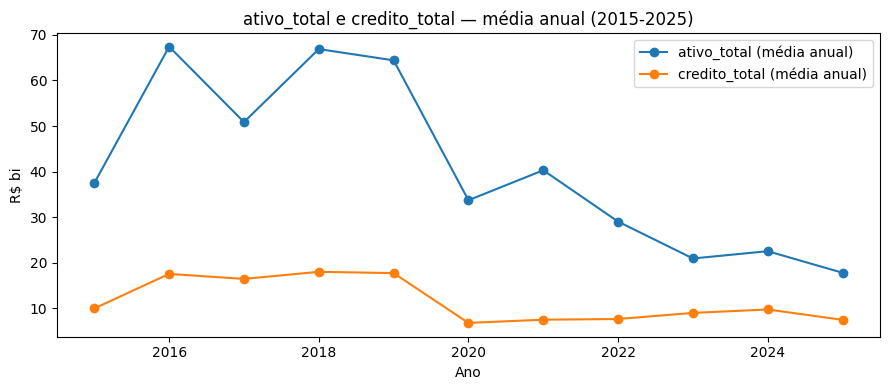

In [ ]:
anual = painel.groupby('ano')[['ativo_total', 'credito_total']].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anual.index, anual['ativo_total'] / 1e9, marker='o', label='ativo_total (média anual)')
ax.plot(anual.index, anual['credito_total'] / 1e9, marker='o', label='credito_total (média anual)')
ax.set_ylabel('R$ bi')
ax.set_xlabel('Ano')
ax.set_title('ativo_total e credito_total — média anual (2015-2025)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f'{v:,.0f}'.replace(',', '.')))
plt.tight_layout()
plt.show()

In [ ]:
ativo_2019 = anual.loc[2019, 'ativo_total']
ativo_2020 = anual.loc[2020, 'ativo_total']
credito_2019 = anual.loc[2019, 'credito_total']
credito_2020 = anual.loc[2020, 'credito_total']

queda_ativo = (1 - ativo_2020 / ativo_2019) * 100
queda_credito = (1 - credito_2020 / credito_2019) * 100

variacoes = anual['ativo_total'].pct_change().drop(2020) * 100
maior_alta = variacoes.max()
maior_queda_fora_2020 = variacoes.min()

texto = (
    f"**ativo_total**: {ativo_2019/1e9:,.1f} bi (2019) → {ativo_2020/1e9:,.1f} bi (2020), "
    f"queda de **{queda_ativo:.0f}%** num ano só — a maior queda anual de toda a série.\n\n"
    f"**credito_total**: {credito_2019/1e9:,.1f} bi (2019) → {credito_2020/1e9:,.1f} bi (2020), "
    f"queda de **{queda_credito:.0f}%** num ano só.\n\n"
    f"**Mas atenção pra moldura certa**: a série inteira é volátil, não só em 2019-2020. A variação "
    f"ano a ano de `ativo_total` no resto da série vai de {maior_queda_fora_2020:.0f}% até "
    f"**+{maior_alta:.0f}%** (2016) — ou seja, há uma alta anual maior, em módulo, que a própria queda "
    f"de 2020. A queda de {queda_ativo:.0f}% em 2020 é real e é a maior queda de um ano só em toda a "
    f"série, mas **não é uma anomalia isolada** — é a maior de várias oscilações grandes que essa série "
    f"tem o tempo todo (2022 e 2023 também caem ~28% cada). A pergunta certa não é 'o que quebrou em "
    f"2019-2020', e sim 'por que essa série é estruturalmente volátil' — o que enfraquece ainda mais a "
    f"hipótese de que um fator gradual e monotônico como fechamento de agências explique o padrão."
)
display(Markdown(texto))


**ativo_total**: 64.4 bi (2019) → 33.7 bi (2020), queda de **48%** num ano só — a maior queda anual de toda a série.

**credito_total**: 17.8 bi (2019) → 6.8 bi (2020), queda de **62%** num ano só.

**Mas atenção pra moldura certa**: a série inteira é volátil, não só em 2019-2020. A variação ano a ano de `ativo_total` no resto da série vai de -28% até **+80%** (2016) — ou seja, há uma alta anual maior, em módulo, que a própria queda de 2020. A queda de 48% em 2020 é real e é a maior queda de um ano só em toda a série, mas **não é uma anomalia isolada** — é a maior de várias oscilações grandes que essa série tem o tempo todo (2022 e 2023 também caem ~28% cada). A pergunta certa não é 'o que quebrou em 2019-2020', e sim 'por que essa série é estruturalmente volátil' — o que enfraquece ainda mais a hipótese de que um fator gradual e monotônico como fechamento de agências explique o padrão.

## 2. Testando a hipótese das agências

A hipótese: parte da queda vem do fechamento de agências bancárias físicas em Santos — o `ativo_total`/`credito_total` do ESTBAN soma o balanço das agências *sediadas no município*, então se um banco fecha sua agência em Santos (mesmo mantendo crédito às empresas por canais digitais ou agência em outra praça), o número reportado para Santos cai, sem que isso signifique necessariamente uma contração real da atividade econômica local.

Testar isso exige, por definição, saber de quem é cada agência: a alternativa a "o mercado como um todo mudou" sempre foi "um agente específico distorceu o agregado", e essa alternativa só é testável olhando por banco. Por isso a série usada aqui já vem quebrada por instituição desde o início (`estban_agencias_santos_2015-2025_por_banco.csv`), e não como um patch reservado a um ano suspeito.

Cada banco reporta um único valor de `agencias_processadas` por mês (contagem de `cnpj_agencia` distintos, já sem duplicação de verbete contábil). Antes de somar por mês (agregando todos os bancos) e de calcular qualquer correlação, vale confirmar que nenhum banco tem um mês simplesmente **ausente** dentro da própria janela em que opera em Santos — isso indicaria buraco de reporte, não fechamento real (um fechamento real aparece como banco que some e não volta, não como buraco pontual no meio da janela).


In [ ]:
# Pra cada banco, verifica se falta algum mês dentro da própria janela ativa em Santos
# (do primeiro ao último mês em que ele aparece na fonte) — mês ausente = suspeita de
# buraco de reporte, não fechamento real (fechamento real aparece como banco que some
# e não volta, não como buraco pontual no meio da janela).
registros = []
for cnpj, g in agencias_por_banco.groupby('cnpj_basico'):
    g = g.sort_values(['ano', 'mes'])
    inst = g['instituicao'].iloc[0]
    primeiro, ultimo = g.iloc[0], g.iloc[-1]
    janela = pd.period_range(start=f"{primeiro.ano}-{primeiro.mes:02d}",
                              end=f"{ultimo.ano}-{ultimo.mes:02d}", freq='M')
    presentes = pd.PeriodIndex(g['ano'].astype(str) + '-' + g['mes'].astype(str).str.zfill(2), freq='M')
    faltando = janela.difference(presentes)
    if len(faltando):
        registros.append({
            'instituicao': inst, 'cnpj_basico': cnpj,
            'meses_ausentes': len(faltando),
            'primeiro_ausente': str(faltando.min()),
            'ultimo_ausente': str(faltando.max()),
        })

buracos = pd.DataFrame(registros)
buracos


**Resultado: buraco de reporte só aparece em 2025.** Checando a janela inteira 2015-2025, alguns bancos têm mês ausente dentro da própria janela ativa — mas em todos os casos a ausência cai em 2025 (Itaú, Santander e BB, cada um numa janela diferente — ver tabela acima). Nenhum ano anterior, incluindo 2016, 2020, 2022 e 2023 (os anos com as maiores oscilações vistas na seção 1), tem banco com mês ausente dentro da própria janela ativa.

Isso é um resultado relevante para a seção 1: a volatilidade grande de `ativo_total`/`credito_total` em anos como 2016 ou 2020 **não pode ser explicada, ao menos por essa fonte, como artefato de buraco de reporte** — pelo menos não no nível de agências físicas. Continua sendo volatilidade real (ou tem outra causa fora do que essa fonte consegue testar), não um problema de qualidade de dado disfarçado de volatilidade.

**Tratamento para 2025, ainda não aplicado:** tratar `agencias_processadas` como ausente (NaN) nos meses/bancos acima e então decidir — interpolar, excluir o mês do total, ou excluir 2025 inteiro de qualquer análise que use a série de agências — antes de usar esse ano em conjunto com `ativo_total`/`credito_total`. **A série de agências é confiável de 2015 a 2024, sem essa ressalva; 2025 não é, sem esse tratamento.**


In [ ]:
agencias_confiavel = agencias[agencias['ano'] <= 2024].copy()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(agencias_confiavel['ano'] + (agencias_confiavel['mes'] - 1) / 12,
         agencias_confiavel['total_agencias_santos'], color='steelblue')
ax1.set_ylabel('Nº de agências em Santos', color='steelblue')
ax1.set_xlabel('Ano')
ax1.set_title('Número de agências em Santos (2015-2024) vs ativo_total')

ax2 = ax1.twinx()
painel_2024 = painel[painel['ano'] <= 2024]
ax2.plot(painel_2024['ano'] + (painel_2024['mes'] - 1) / 12,
         painel_2024['ativo_total'] / 1e9, color='firebrick', alpha=0.6)
ax2.set_ylabel('ativo_total (R$ bi)', color='firebrick')

plt.tight_layout()
plt.show()


In [ ]:
# junta agências com o painel pra calcular a correlação de verdade
base_corr = agencias_confiavel.merge(painel, on=['ano', 'mes'], how='inner')
corr_ativo = base_corr['total_agencias_santos'].corr(base_corr['ativo_total'])
corr_credito = base_corr['total_agencias_santos'].corr(base_corr['credito_total'])

agencias_anual = agencias_confiavel.groupby('ano')['total_agencias_santos'].mean()
queda_agencias_total = (1 - agencias_anual.loc[2024] / agencias_anual.loc[2015]) * 100

texto = (
    f"Correlação (2015-2024, mensal): **{corr_ativo:.2f}** entre nº de agências e `ativo_total`; "
    f"**{corr_credito:.2f}** entre nº de agências e `credito_total`. Positiva, mas moderada — não é "
    f"forte o suficiente pra sozinha carregar a explicação do padrão.\n\n"
    f"O motivo aparece no formato das duas séries: o número de agências caiu {queda_agencias_total:.0f}% "
    f"entre 2015 e 2024 de forma **suave e monotônica** (~2 agências por ano, sem nenhuma reversão), "
    f"enquanto `ativo_total` é **volátil pra cima e pra baixo o tempo todo** (visto na seção 1: alta de "
    f"+80% em 2016, quedas de ~28% em 2022 e 2023, além da queda de 2020). Uma série que só desce "
    f"devagar não consegue explicar oscilações grandes em ambas as direções.\n\n"
    f"**Conclusão desta seção:** o fechamento de agências é um fator estrutural real, coerente com a "
    f"tendência de queda de longo prazo de `ativo_total`/`credito_total` — mas explica só uma fração "
    f"pequena e constante da queda, não a volatilidade ano a ano. A causa da volatilidade em si (por que "
    f"`ativo_total` sobe 80% num ano e cai 28% em outros) segue sem explicação; fica registrada como "
    f"pergunta em aberto pro grupo, não resolvida aqui."
)
display(Markdown(texto))


## Resumo da investigação

- `ativo_total`/`credito_total` **não têm uma quebra pontual isolada em 2019-2020** — essa era a hipótese inicial, mas os dados não sustentam. O que existe, de fato, é uma **volatilidade estrutural** ao longo de toda a série: altas de até +80% num ano (2016) e quedas de até -48% (2020), -28% (2022, 2023). 2020 é a maior queda anual, mas não é isolada — é a mais extrema de várias oscilações grandes.
- O fechamento de agências bancárias em Santos é um fator estrutural real e correlacionado (correlação moderada, ~0,50), mas seu padrão é **suave e monotônico** — não consegue explicar uma série que oscila com essa intensidade em ambas as direções. Explica uma fração pequena e constante da queda de longo prazo, não a volatilidade.
- A checagem de mês ausente por banco, rodada para 2015-2025 inteiro, **não encontrou buraco de reporte fora de 2025** — o que descarta, ao menos nesta fonte, a hipótese de que os saltos grandes da série (2016, 2020, 2022, 2023) sejam artefato de qualidade de dado disfarçado de volatilidade real.
- A causa real da volatilidade ano a ano segue **sem explicação** — fica como pergunta em aberto pro grupo, a ser retomada nos passos de Correlação e Estacionariedade/Decomposição do roteiro de EDA.
- A série de agências tem um problema de qualidade de dado em 2025 (buracos de reporte por banco, meses ausentes em Itaú, Santander e BB) que precisa ser tratado antes de ser usada em conjunto com `ativo_total`/`credito_total` — registrado aqui, não resolvido. A série é confiável de 2015 a 2024.
